# Engineer one Reid network

Known-case refactor verification for Reid-84. The historical frozen z1 readout is response-calibrated; LAMMPS is final-only verification after graph hashes are frozen.

In [1]:
%matplotlib inline
from datetime import datetime, timezone
from pathlib import Path
import sys
import torch

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / 'src'))
sys.path.insert(1, '/rg/mendels_prj/alexander.z/MetaForge/src')

from lss.engineering import OptimizationConfig, load_model, load_network, optimize_network
from lss.plotting import apply_editorial_style

apply_editorial_style()
torch.set_num_threads(1)
BUNDLE = ROOT / 'models/engineering/reid_frozen_ae.pt'
DATASET = ROOT / 'data/reid_200_frames.pt'
LAMMPS = Path('/rg/mendels_prj/alexander.z/DL-course-project/.runtime/lammps/bin/lmp')
ASSETS = Path.cwd() / 'Engineer one Reid network'
ASSETS.mkdir(exist_ok=True)
RUN = ROOT / 'runs/engineering' / f"reid84_known_case_{datetime.now(timezone.utc):%Y%m%dT%H%M%SZ}"
config = OptimizationConfig(learning_rate=.08, stiffness_bound=.25, patience=50, max_steps=1200, mask_blocking_nodes=True)
model = load_model(BUNDLE)
network = load_network(DATASET, 84, 'reid')

initial=0.043595; best=-1.030291; steps=565; stop=patience_50


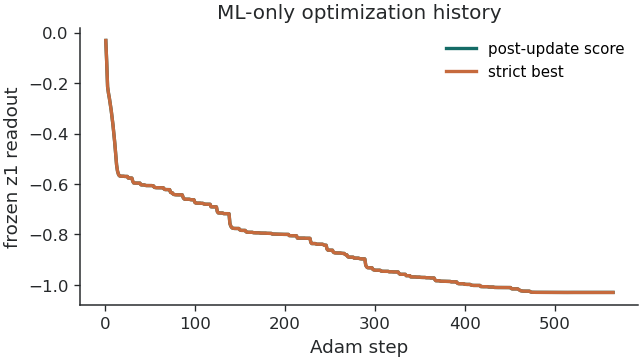

In [2]:
import matplotlib.pyplot as plt

result = optimize_network(model, network, config)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(result.history['step'], result.history['predicted_p'], color='#146b66', label='post-update score')
ax.plot(result.history['step'], result.history['best_score'], color='#c66a3d', label='strict best')
ax.set(xlabel='Adam step', ylabel='frozen z1 readout', title='ML-only optimization history')
ax.legend(frameon=False)
print(f'initial={result.initial_score:.6f}; best={result.best_score:.6f}; steps={result.steps}; stop={result.stop_reason}')

In [3]:
from lss.engineering import freeze_final_designs, verify_frozen_designs

manifest = freeze_final_designs(result, RUN, dataset_path=DATASET, known_case_refactor_verification=True)
verification = verify_frozen_designs(RUN, LAMMPS)
print('Final designs saved and verified.')

Network written to /rg/mendels_prj/alexander.z/latent-space-simulators/runs/engineering/reid84_known_case_20260909T070419Z/verification/original/network.lmp


Network written to /rg/mendels_prj/alexander.z/latent-space-simulators/runs/engineering/reid84_known_case_20260909T070419Z/verification/optimized/network.lmp


Final designs saved and verified.


,design,physical_p_ratio,endpoint_parity_error,frames
0,original,0.145364,0.0,121
1,optimized,-0.187439,0.0,121


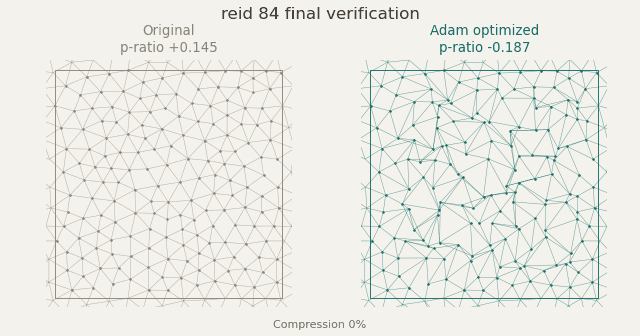

In [4]:
import json
import pandas as pd
import shutil
from IPython.display import Image, display
from lss.engineering import render_comparison

comparison = pd.DataFrame([{'design': name, 'physical_p_ratio': row['physical_p_ratio'], 'endpoint_parity_error': row['endpoint_parity_error'], 'frames': row['frame_count']} for name, row in verification.items()])
gif = render_comparison(RUN)
published_gif = ASSETS / gif.name
shutil.copy2(gif, published_gif)
(ASSETS / 'latest_run.json').write_text(json.dumps({'run_dir': str(RUN.resolve()), 'manifest': manifest, 'gif': str(published_gif.resolve())}, indent=2) + '\n')
display(comparison)
display(Image(filename=str(published_gif)))